# 개요

- BA의 $H$ 는 크지만 거의 비어 있다. 그 구조를 쓰면 landmark 변수를 **대입 한 번으로 지울 수 있다.**
- dense로 푸는 것과 Schur complement로 푸는 것이 같은 답을 주는지, 그리고 비용이 얼마나 차이나는지 잰다.

# 1. 희소성과 Schur Complement

- `dense 풀이` $(6P + 3L)^{3}$
	- 변수 전부를 한 번에. landmark가 늘면 곧바로 죽는다
- `Schur complement` $P^{3} + L$
	- landmark를 먼저 소거하고 pose만 푼다. $H_{ll}$ 이 블록 대각이라 소거가 공짜다

---
## 1.1. Hessian의 구조

pose와 landmark를 나눠 정렬하면 `arrowhead` 모양이 된다.

$$
\boxed{
H = \begin{bmatrix} H_{pp} & H_{pl} \\ H_{pl}^{T} & H_{ll} \end{bmatrix},
\qquad
\begin{bmatrix} \delta_{p} \\ \delta_{l} \end{bmatrix},
\qquad
b = -g = \begin{bmatrix} b_{p} \\ b_{l} \end{bmatrix}
}
$$

- $H_{pp}$: $(6P, 6P)$, $H_{ll}$: $(3L, 3L)$, $H_{pl}$: $(6P, 3L)$

```txt
        pose (6P)         landmark (3L)
      +-------------+-------------------+
pose  |   H_pp      |      H_pl         |  H_pl : 관측이 있는 (i,j) 쌍만 채워진다
      +-------------+-------------------+
land  |   H_pl^T    |      H_ll         |  H_ll : 완전 블록 대각 (3x3 x L 개)
      +-------------+-------------------+

H_ll 이 블록 대각인 이유:
  두 landmark 를 직접 잇는 관측이 없다. 어떤 잔차도 X_j 와 X_k 를 동시에 건드리지 않으므로
  off-diagonal 블록이 구조적으로 0 이다.
  => H_ll^-1 이 3x3 역행렬 L 개로 분해된다. 이게 Schur 를 싸게 만드는 전부다.
```

---
## 1.2. Landmark를 소거한다

아래 블록 $H_{pl}^{T}\delta_{p} + H_{ll}\delta_{l} = b_{l}$ 에서 $\delta_l$ 을 풀어

$$ \delta_{l} = H_{ll}^{-1}\left(b_{l} - H_{pl}^{T}\delta_{p}\right) $$

위 블록에 대입하면 pose만의 훨씬 작은 시스템이 남는다.

$$
\boxed{
\left(H_{pp} - H_{pl}H_{ll}^{-1}H_{pl}^{T}\right)\delta_{p} = b_{p} - H_{pl}H_{ll}^{-1}b_{l}
}
$$

즉,

> landmark는 풀지 않고 대입해서 지운다. 남는 것은 pose 크기 문제뿐이다

$\delta_p$ 를 얻은 뒤 위 식으로 $\delta_l$ 을 되돌린다.

$$
\boxed{
\delta_{l} = H_{ll}^{-1}\left(b_{l} - H_{pl}^{T}\delta_{p}\right)
}
$$

---
## 1.3. 게이지 고정

이 문제에는 전역 SE(3) 자유도가 남아 있다. 전체를 같이 회전·이동시켜도 관측이 변하지 않으므로
$H$ 의 rank가 정확히 6 모자란다. pose 0 을 고정해 그 6차원을 없앤다.

$$ \delta\xi_{0} = 0 \quad\Longrightarrow\quad \text{free} = [6, 6P) $$

---
## 1.4. 전체 파이프라인

$$ \boxed{ \text{obs} \rightarrow H_{pp}, H_{pl}, H_{ll}, b \rightarrow \text{pose 0 고정} \rightarrow S\,\delta_{p} = b_{S} \rightarrow \delta_{l} \rightarrow \text{retraction} } $$

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

# numpy 2.x + Apple Accelerate 조합에서 matmul 이 부동소수점 상태 플래그를 잘못 남긴다.
# 결과값은 전부 정상이라(직접 대조해 확인했다) 이 조합에서만 나오는 잡음만 끈다.
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)


def pick_korean_font():
    """한글과 수학 마이너스(U+2212)를 **둘 다** 가진 폰트를 우선 고른다.

    로그 축 눈금은 $\mathdefault{10^{-13}}$ 로 그려지는데, mathtext 는 여기서 font.family 를
    쓴다. AppleGothic 계열에는 U+2212 가 없어서 지수의 마이너스가 네모로 깨진다 —
    한글은 멀쩡해서 알아채기 어렵다.
    """
    available = {f.name for f in font_manager.fontManager.ttflist}
    candidates = ("Arial Unicode MS", "Noto Sans CJK KR", "NanumGothic",
                  "Malgun Gothic", "Apple SD Gothic Neo", "AppleGothic")
    fallback = None
    for name in candidates:
        if name not in available:
            continue
        fallback = fallback or name
        try:
            path = font_manager.findfont(font_manager.FontProperties(family=name),
                                         fallback_to_default=False)
            if font_manager.get_font(path).get_char_index(0x2212):
                return name, True
        except Exception:
            continue
    return fallback, False


_font, _has_minus = pick_korean_font()
if _font:
    plt.rcParams["font.family"] = _font
    plt.rcParams["axes.unicode_minus"] = _has_minus   # 없으면 ASCII 하이픈으로 대체
    plt.rcParams["mathtext.fontset"] = "dejavusans"
print(f"font: {_font}  (U+2212 보유: {_has_minus})")

font: Arial Unicode MS  (U+2212 보유: True)


## 0. 샘플 데이터 생성하기

- pose가 landmark를 관측하는 작은 BA. 관측 모델은 $z_{ij} = R_{i}^{T}(X_{j} - t_{i})$ 이다.
- 참값과 흔든 초기값을 함께 받는다. pose 0 은 게이지라 흔들지 않는다.

In [2]:
import importlib
import problems
importlib.reload(problems)                 # 커널을 재시작하지 않아도 최신 버전을 반영
from problems import *

data = make_toy_ba(n_pose=6, n_land=40, observed=0.6, noise=0.01, seed=0)

n_pose, n_land = len(data["Rs"]), len(data["Xs"])
print("pose %d, landmark %d, 관측 %d 개" % (n_pose, n_land, len(data["obs"])))
print("변수 차원: pose %d + landmark %d = %d"
      % (6 * n_pose, 3 * n_land, 6 * n_pose + 3 * n_land))
print("초기 pose 오차    : %.4f" % np.abs(data["ts_init"] - data["ts"]).max())
print("초기 landmark 오차: %.4f" % np.abs(data["Xs_init"] - data["Xs"]).max())

pose 6, landmark 40, 관측 139 개
변수 차원: pose 36 + landmark 120 = 156
초기 pose 오차    : 0.1013
초기 landmark 오차: 0.2342


# 1. 데이터 시각화

$H$ 의 희소 패턴을 먼저 본다. 이 그림이 이 노트북의 전제 전체다.

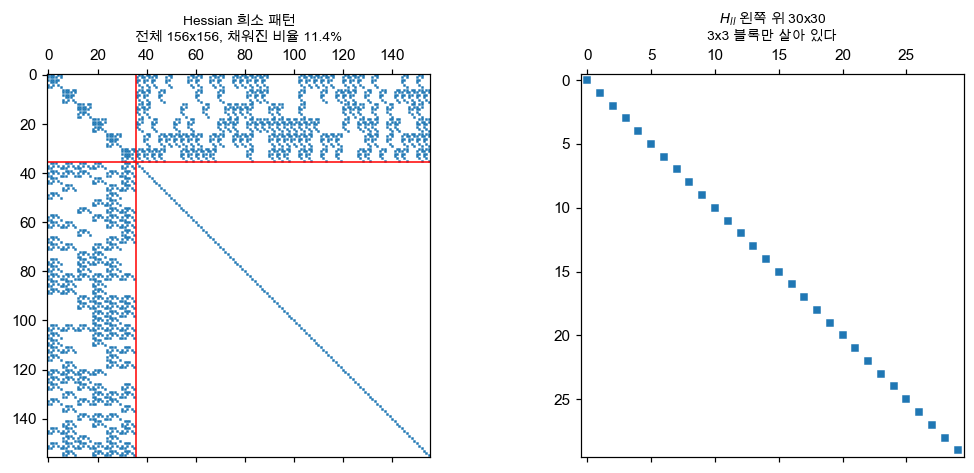

초기 비용 F = 2.170630


In [3]:
def show_sparsity(Hpp, Hpl, Hll, title="Hessian 희소 패턴"):
    """0 이 아닌 원소만 찍는다. arrowhead 와 H_ll 의 블록 대각이 보여야 한다."""
    P, L = Hpp.shape[0], Hll.shape[0]
    H = np.block([[Hpp, Hpl], [Hpl.T, Hll]])      # (P+L, P+L)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
    axes[0].spy(np.abs(H) > 1e-12, markersize=0.6)
    axes[0].axhline(P - 0.5, color="r", lw=1); axes[0].axvline(P - 0.5, color="r", lw=1)
    axes[0].set_title(f"{title}\n전체 {H.shape[0]}x{H.shape[0]}, "
                      f"채워진 비율 {np.mean(np.abs(H) > 1e-12):.1%}", fontsize=9)

    axes[1].spy(np.abs(Hll[:30, :30]) > 1e-12, markersize=4)
    axes[1].set_title("$H_{ll}$ 왼쪽 위 30x30\n3x3 블록만 살아 있다", fontsize=9)
    plt.tight_layout(); plt.show()


Hpp, Hpl, Hll, bp, bl, cost = ba_residual_and_jacobian(
    data["Rs_init"], data["ts_init"], data["Xs_init"], data["obs"])
show_sparsity(Hpp, Hpl, Hll)
print("초기 비용 F = %.6f" % cost)

# 2. Dense와 Schur

박스 수식 하나에 셀 하나씩.

In [4]:
# 1. 게이지 고정 - pose 0 을 빼서 rank 결핍 6 을 없앤다
def free_indices(n_pose):
    """pose 0 의 6개 자유도를 제외한 인덱스."""
    return np.arange(6, 6 * n_pose)

In [5]:
# 2. H_ll^-1 - 블록 대각이므로 3x3 역행렬 L 개로 분해된다
def invert_block_diagonal(Hll, block=3):
    """(3L, 3L) 을 (L, 3, 3) 으로 재배열해 한 번에 역행렬을 구한다.

    전체를 np.linalg.inv 에 넣으면 O((3L)^3) 이지만, 블록 대각을 쓰면 3x3 을 L 번이라 O(L) 이다.
    Schur 가 싼 이유가 정확히 이 함수에 있다.
    """
    L = Hll.shape[0] // block
    blocks = np.empty((L, block, block))
    for j in range(L):
        s = slice(block * j, block * j + block)
        blocks[j] = Hll[s, s]
    return np.linalg.inv(blocks)                  # (L, 3, 3) — 배치로 한 번에


def block_diag_matmul(Hpl, Hll_inv, block=3):
    """Y = H_pl @ H_ll^-1 을 블록 단위로. (6P, 3L) @ (3L, 3L) 을 통째로 하지 않는다."""
    Y = np.empty_like(Hpl)
    for j in range(Hll_inv.shape[0]):
        s = slice(block * j, block * j + block)
        Y[:, s] = Hpl[:, s] @ Hll_inv[j]
    return Y

In [6]:
# 3. Schur complement - (H_pp - H_pl H_ll^-1 H_pl^T) d_p = b_p - H_pl H_ll^-1 b_l
def solve_schur(Hpp, Hpl, Hll, bp, bl, lam=1e-6):
    """반환: (delta_pose, delta_land)"""
    # damping 을 먼저 걸어야 H_ll 이 확실히 가역이다 (관측 1회짜리 landmark 대비)
    Hpp_d = Hpp + lam * np.diag(np.maximum(np.diag(Hpp), 1.0))
    Hll_inv = invert_block_diagonal(Hll + lam * np.diag(np.maximum(np.diag(Hll), 1.0)))

    Y = block_diag_matmul(Hpl, Hll_inv)           # (6P, 3L)
    S = Hpp_d - Y @ Hpl.T                         # (6P, 6P)  Schur complement
    b_S = bp - Y @ bl                             # (6P,)

    delta_p = np.linalg.solve(S, b_S)
    # 4. 되돌리기 - d_l = H_ll^-1 (b_l - H_pl^T d_p)
    rhs = bl - Hpl.T @ delta_p                    # (3L,)
    delta_l = np.concatenate([Hll_inv[j] @ rhs[3 * j:3 * j + 3]
                              for j in range(Hll_inv.shape[0])])
    return delta_p, delta_l

In [7]:
# 4. dense 풀이 - 비교 기준. 전체를 한 번에 푼다
def solve_dense(Hpp, Hpl, Hll, bp, bl, lam=1e-6):
    H = np.block([[Hpp, Hpl], [Hpl.T, Hll]])      # (6P+3L, 6P+3L)
    H = H + lam * np.diag(np.maximum(np.diag(H), 1.0))
    b = np.concatenate([bp, bl])
    delta = np.linalg.solve(H, b)
    return delta[:Hpp.shape[0]], delta[Hpp.shape[0]:]

In [8]:
# 5. retraction - 왼쪽 섭동 R <- exp(dtheta) R, t <- exp(dtheta) t + dt
def apply_update(Rs, ts, Xs, delta_p, delta_l, n_pose):
    """pose 0 은 고정이므로 delta_p 는 pose 1 부터 대응한다."""
    Rs, ts, Xs = Rs.copy(), ts.copy(), Xs.copy()
    for k, i in enumerate(range(1, n_pose)):
        dtheta, dt = delta_p[6 * k:6 * k + 3], delta_p[6 * k + 3:6 * k + 6]
        E = so3_exp(dtheta)                       # (3, 3)
        Rs[i] = E @ Rs[i]
        ts[i] = E @ ts[i] + dt
    Xs = Xs + delta_l.reshape(-1, 3)
    return Rs, ts, Xs

## 2.1. 메인 루프

번호 주석이 1.4절 파이프라인과 대응한다.

In [9]:
Rs, ts, Xs = data["Rs_init"].copy(), data["ts_init"].copy(), data["Xs_init"].copy()
free = free_indices(n_pose)
cost_history, pose_err, land_err = [], [], []

for it in range(10):
    # 1. 잔차 -> H, b (arrowhead 블록으로 바로 받는다)
    Hpp, Hpl, Hll, bp, bl, cost = ba_residual_and_jacobian(Rs, ts, Xs, data["obs"])
    cost_history.append(cost)
    pose_err.append(np.abs(ts - data["ts"]).max())
    land_err.append(np.abs(Xs - data["Xs"]).max())

    # 2. 게이지 고정 - pose 0 제거
    Hpp_f, Hpl_f, bp_f = Hpp[np.ix_(free, free)], Hpl[free], bp[free]

    # 3. Schur 로 풀고
    delta_p, delta_l = solve_schur(Hpp_f, Hpl_f, Hll, bp_f, bl)

    # 4. retraction
    Rs, ts, Xs = apply_update(Rs, ts, Xs, delta_p, delta_l, n_pose)

print("F: %.6f -> %.6f" % (cost_history[0], cost_history[-1]))
print("pose 오차    : %.4f -> %.4f" % (pose_err[0], pose_err[-1]))
print("landmark 오차: %.4f -> %.4f" % (land_err[0], land_err[-1]))

F: 2.170630 -> 0.012982
pose 오차    : 0.1013 -> 0.0153
landmark 오차: 0.2342 -> 0.0211


# 3. 검증

두 가지를 확인한다. **같은 답인가**, 그리고 **얼마나 빠른가**.

In [10]:
# 같은 답인가 - Schur 는 근사가 아니라 정확한 소거다
Hpp, Hpl, Hll, bp, bl, _ = ba_residual_and_jacobian(
    data["Rs_init"], data["ts_init"], data["Xs_init"], data["obs"])
Hpp_f, Hpl_f, bp_f = Hpp[np.ix_(free, free)], Hpl[free], bp[free]

dp_s, dl_s = solve_schur(Hpp_f, Hpl_f, Hll, bp_f, bl)
dp_d, dl_d = solve_dense(Hpp_f, Hpl_f, Hll, bp_f, bl)

print("pose     최대 차이 : %.3e" % np.abs(dp_s - dp_d).max())
print("landmark 최대 차이 : %.3e" % np.abs(dl_s - dl_d).max())
print("\n부동소수점 오차 수준이면 Schur 가 정확한 소거임이 확인된 것이다.")

pose     최대 차이 : 2.776e-16
landmark 최대 차이 : 3.886e-16

부동소수점 오차 수준이면 Schur 가 정확한 소거임이 확인된 것이다.


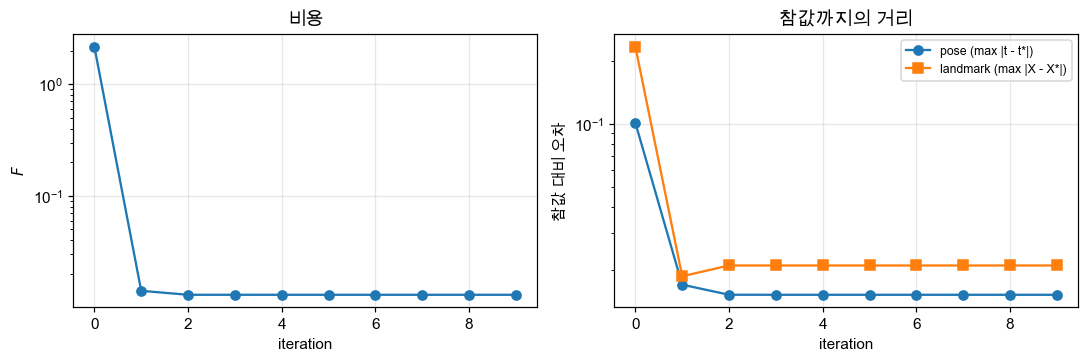

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].semilogy(cost_history, "o-"); axes[0].set_xlabel("iteration")
axes[0].set_ylabel("$F$"); axes[0].set_title("비용"); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(pose_err, "o-", label="pose (max |t - t*|)")
axes[1].semilogy(land_err, "s-", label="landmark (max |X - X*|)")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("참값 대비 오차")
axes[1].set_title("참값까지의 거리"); axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3.1. landmark 수에 따른 비용

pose는 6개로 고정하고 landmark만 늘린다. dense는 $(36 + 3L)^{3}$, Schur는 $36^{3} + O(L)$ 이므로
기울기가 달라야 한다.

In [12]:
import time

land_counts = (20, 40, 80, 160, 320, 640)
timing = {"dense": [], "schur": []}
dims = []

for n_l in land_counts:
    d = make_toy_ba(n_pose=6, n_land=n_l, observed=0.6, noise=0.01, seed=0)
    Hpp_k, Hpl_k, Hll_k, bp_k, bl_k, _ = ba_residual_and_jacobian(
        d["Rs_init"], d["ts_init"], d["Xs_init"], d["obs"])
    f = free_indices(6)
    args = (Hpp_k[np.ix_(f, f)], Hpl_k[f], Hll_k, bp_k[f], bl_k)
    dims.append(args[0].shape[0] + Hll_k.shape[0])

    for name, solve in (("dense", solve_dense), ("schur", solve_schur)):
        solve(*args)                                        # 워밍업 (BLAS 초기화)
        t0 = time.perf_counter()
        for _ in range(3):
            solve(*args)
        timing[name].append((time.perf_counter() - t0) / 3)

print(f"{'landmark':>9s} {'차원':>7s} {'dense[ms]':>11s} {'schur[ms]':>11s} {'배율':>8s}")
for k, n_l in enumerate(land_counts):
    d_ms, s_ms = timing["dense"][k] * 1e3, timing["schur"][k] * 1e3
    print(f"{n_l:9d} {dims[k]:7d} {d_ms:11.2f} {s_ms:11.2f} {d_ms / s_ms:8.1f}x")

 landmark      차원   dense[ms]   schur[ms]       배율
       20      90        0.05        0.08      0.7x
       40     150        0.14        0.13      1.1x
       80     270        0.27        0.22      1.2x
      160     510        1.40        0.53      2.7x
      320     990        5.73        1.27      4.5x
      640    1950       26.24        3.80      6.9x


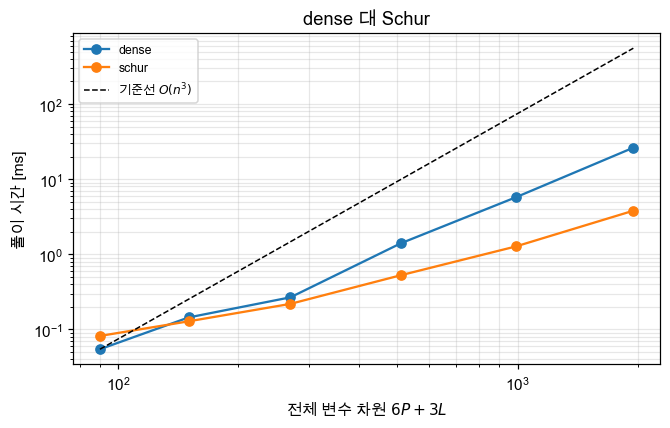

로그-로그 기울기   dense: 2.02   schur: 1.25


In [13]:
plt.figure(figsize=(6.2, 4.0))
for name in ("dense", "schur"):
    plt.loglog(dims, np.array(timing[name]) * 1e3, "o-", label=name)

ref = np.array(dims, dtype=float)
plt.loglog(ref, timing["dense"][0] * 1e3 * (ref / ref[0]) ** 3, "k--", lw=1,
           label=r"기준선 $O(n^3)$")
plt.xlabel("전체 변수 차원 $6P + 3L$"); plt.ylabel("풀이 시간 [ms]")
plt.title("dense 대 Schur"); plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

slope = lambda y: np.polyfit(np.log10(dims), np.log10(y), 1)[0]
print("로그-로그 기울기   dense: %.2f   schur: %.2f" % (slope(timing["dense"]), slope(timing["schur"])))

## 3.2. 한계

- $H$ 를 **dense 배열로** 만들고 있다. 진짜 구현은 `scipy.sparse` 나 전용 블록 구조를 쓰므로
  $H_{pp}$ 조립 비용도 훨씬 싸다. 여기서 재는 것은 **풀이 단계**의 차이뿐이다.
- Schur 이후의 $S$ 는 pose 그래프의 인접 구조를 따라 여전히 희소하다. 그것까지 쓰려면
  ordering(COLAMD/AMD)과 희소 Cholesky가 필요하다 — 로드맵 6.3절.
- landmark가 여러 pose에 걸쳐 관측될수록 $S$ 가 조밀해진다. 극단적으로 모든 pose가 모든
  landmark를 보면 Schur의 이점이 사라진다.
- `observed=0.6` 이라 landmark당 평균 3.6회 관측이다. 관측이 1회뿐인 landmark는 $H_{ll}$ 블록이
  겨우 가역이라, damping 없이는 위험하다.